<a href="https://colab.research.google.com/github/Nico-Cartes-dev/mineria-datos/blob/main/f1_corregido_mineria_dat_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Minería de Datos
## Impacto de la IA en el Mercado Laboral (2010–2025)

---

## 0. Montaje de Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 2. Carga del Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ai_impact_jobs_2010_2025.csv")
display(df.head())

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,South America,London,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Middle East,Singapore,Future Solutions,Medium,Energy,Data Scientist,Executive,False,NaN,0.04,"Research, SQL, Business Analysis, Python, Clou...",NaN,62045,-3.98,0.71,False,High,19,Emerging
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,South Asia,Sydney,Future Analytics,Startup,Finance,Product Manager,Junior,False,NaN,0.15,"Statistics, Project Management, Cloud Computin...",NaN,27035,3.55,0.86,False,High,2,Emerging
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Europe,Nairobi,Global Technologies,Large,Government,Data Scientist,Mid,False,NaN,0.19,"Cloud Computing, SQL, Project Management, Comm...",NaN,72894,-2.80,0.70,False,Low,15,Emerging
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,East Asia,Sydney,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,NaN,0.11,"SQL, Python, Communication, Software Engineeri...",NaN,57215,0.85,0.87,False,High,13,Emerging


## 3. Exploración Inicial del Dataset

In [ ]:
print("Forma del dataset:", df.shape)
print()
print("Últimas filas:")
display(df.tail())

Forma del dataset: (5000, 22)

Últimas filas:


,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
4995,45aa223b-3ed6-4574-bd07-294a1443c02b,2022,Singapore,Southeast Asia,Bangalore,Prime Analytics,Enterprise,Education,ML Engineer,Intern,False,NaN,0.12,"SQL, Project Management, Data Analysis",NaN,41317,4.62,0.88,False,Low,17,Growing
4996,9f69f4ce-5fe9-44db-9541-478ebe28422b,2018,Chile,South America,Sydney,Future Analytics,Large,Healthcare,Policy Analyst,Senior,False,NaN,0.07,"Software Engineering, Statistics, Business Ana...",NaN,37089,-4.26,0.79,False,Low,13,Growing
4997,0ec6f97e-6dc3-468c-b2a2-ecc087bf067e,2019,Australia,Oceania,Bangalore,Global Solutions,Large,Education,ML Engineer,Mid,False,NaN,0.05,"Project Management, Data Analysis, Business An...",NaN,81651,-4.95,0.64,False,Low,19,Growing
4998,ad529cef-b22e-4e7d-82fd-98fc06d61596,2016,Sweden,Europe,Sydney,NextGen Systems,Enterprise,Energy,AI Researcher,Junior,True,"computer vision, MLOps",0.87,"SQL, Research, Cloud Computing, Communication,...","computer vision, MLOps",107897,-0.23,0.33,True,Low,14,Emerging
4999,79d26161-8cc1-4d98-ab0d-3ebea91f2a1b,2024,India,South Asia,Tokyo,Future Analytics,Enterprise,Tech,Software Engineer,Executive,True,LLMs,0.56,"Software Engineering, Project Management, Busi...",LLMs,35755,11.00,0.10,True,Low,11,Mature


In [ ]:
print("Tipos de datos:")
display(df.dtypes)

Tipos de datos:


,0
job_id,object
posting_year,int64
country,object
region,object
city,object
company_name,object
company_size,object
industry,object
job_title,object
seniority_level,object


In [ ]:
print("Información general:")
df.info()

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   job_id                              5000 non-null   object 
 1   posting_year                        5000 non-null   int64  
 2   country                             5000 non-null   object 
 3   region                              5000 non-null   object 
 4   city                                5000 non-null   object 
 5   company_name                        5000 non-null   object 
 6   company_size                        5000 non-null   object 
 7   industry                            5000 non-null   object 
 8   job_title                           5000 non-null   object 
 9   seniority_level                     5000 non-null   object 
 10  ai_mentioned                        5000 non-null   bool   
 11  ai_keywords           

In [ ]:
print("Estadísticas descriptivas:")
display(df.describe().round())

Estadísticas descriptivas:


,posting_year,ai_intensity_score,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,job_description_embedding_cluster
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,2018.0,0.0,63096.0,3.0,1.0,9.0
std,5.0,0.0,31431.0,6.0,0.0,6.0
min,2010.0,0.0,15321.0,-5.0,0.0,0.0
25%,2013.0,0.0,36576.0,-2.0,0.0,4.0
50%,2017.0,0.0,60910.0,2.0,1.0,10.0
75%,2022.0,1.0,81812.0,5.0,1.0,14.0
max,2025.0,1.0,161547.0,18.0,1.0,19.0


## 4. Mapeo y Clasificación de Variables

| Variable | Tipo |
|---|---|
| job_id | Identificador (Nominal) |
| posting_year | Numérico Discreto |
| country | Categórico Nominal |
| region | Categórico Nominal |
| city | Categórico Nominal |
| company_name | Categórico Nominal |
| company_size | Categórico Ordinal |
| industry | Categórico Nominal |
| job_title | Categórico Nominal |
| seniority_level | Categórico Ordinal |
| ai_mentioned | Booleano |
| ai_keywords | Categórico Nominal |
| ai_intensity_score | Numérico Continuo |
| core_skills | Categórico Nominal |
| ai_skills | Categórico Nominal |
| salary_usd | Numérico Continuo |
| salary_change_vs_prev_year_percent | Numérico Continuo |
| automation_risk_score | Numérico Continuo |
| reskilling_required | Booleano |
| ai_job_displacement_risk | Categórico Ordinal |
| job_description_embedding_cluster | Numérico Discreto |
| industry_ai_adoption_stage | Categórico Ordinal |

**Clasificación:**
- **Categórico Nominal**: Sin orden (Region, País, Género).
- **Categórico Ordinal**: Con orden lógico (Nivel educacional).
- **Numérico Discreto**: Valores de conteo enteros (N° de hijos).
- **Numérico Continuo**: Valores con decimales (Salario, Puntaje).

## 5. Tratamiento de Valores Nulos

In [ ]:
print("Valores nulos por columna:")
display(df.isnull().sum())

Valores nulos por columna:


,0
job_id,0
posting_year,0
country,0
region,0
city,0
company_name,0
company_size,0
industry,0
job_title,0
seniority_level,0


In [ ]:
# ai_keywords y ai_skills son nulos cuando el trabajo no menciona IA → se rellena con cadena vacía
df['ai_keywords'] = df['ai_keywords'].fillna('')
df['ai_skills'] = df['ai_skills'].fillna('')

print("Verificación post-imputación:")
display(df[['ai_keywords', 'ai_skills']].isnull().sum())

Verificación post-imputación:


,0
ai_keywords,0
ai_skills,0


## 6. Análisis Agrupado de Variables Clave

In [ ]:
print("Distribución por industria:")
display(df["industry"].value_counts())

print("Distribución por país:")
display(df["country"].value_counts())

Distribución por industria:


,count
industry,
Tech,579
Manufacturing,573
Agriculture,569
Retail,567
Healthcare,560
Finance,549
Government,546
Education,535
Energy,522


Distribución por país:


,count
country,
Australia,281
New Zealand,255
United States,207
Mexico,193
Canada,185
Taiwan,159
Japan,138
China,137
Colombia,135


In [ ]:
print("Salario promedio por industria:")
display(df.groupby("industry")["salary_usd"].mean().sort_values(ascending=False).round(1))

Salario promedio por industria:


,salary_usd
industry,
Tech,66262.0
Finance,65276.9
Government,63088.8
Manufacturing,62882.1
Energy,62725.9
Healthcare,62502.0
Education,62098.8
Retail,61822.2
Agriculture,61125.0


In [ ]:
print("Salario promedio por año:")
display(df.groupby("posting_year")["salary_usd"].mean().round(1))

Salario promedio por año:


,salary_usd
posting_year,
2010,47536.2
2011,47875.8
2012,47403.3
2013,50797.1
2014,54188.7
2015,55694.0
2016,56010.4
2017,57176.4
2018,65347.6


In [ ]:
print("Riesgo de automatización promedio por país:")
display(df.groupby("country")["automation_risk_score"].mean().sort_values(ascending=False).round(3))

Riesgo de automatización promedio por país:


,automation_risk_score
country,
Philippines,0.655
Peru,0.630
Bangladesh,0.630
United Kingdom,0.628
South Korea,0.621
Poland,0.619
Sweden,0.618
UAE,0.606
Germany,0.604


In [ ]:
# Salario promedio por región, cargo y seniority
avg_salary_multi = df.groupby(['region', 'job_title', 'seniority_level'])['salary_usd'].mean().round(1).reset_index()
avg_salary_multi = avg_salary_multi.sort_values(by=['region', 'salary_usd'], ascending=[True, False])

print("Top 3 salarios por región:")
display(avg_salary_multi.groupby('region').head(3))

Top 3 salarios por región:


,region,job_title,seniority_level,salary_usd
8,Africa,Business Analyst,Junior,29166.1
2,Africa,AI Researcher,Junior,29047.5
40,Africa,Product Manager,Mid,28066.4
85,East Asia,Operations Manager,Intern,103027.7
71,East Asia,Business Analyst,Senior,89921.2
82,East Asia,ML Engineer,Mid,87922.7
162,Europe,Research Scientist,Executive,101982.3
142,Europe,ML Engineer,Mid,95799.8
153,Europe,Policy Analyst,Lead,93682.1
212,Middle East,Policy Analyst,Junior,91433.2


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 7. Visualizaciones Exploratorias (EDA)

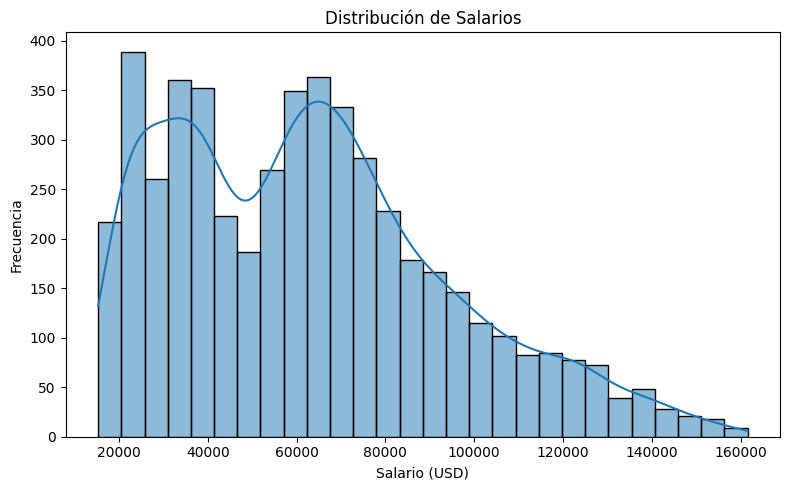

In [ ]:
# Distribución de salarios
plt.figure(figsize=(8, 5))
sns.histplot(df['salary_usd'], kde=True)
plt.title('Distribución de Salarios')
plt.xlabel('Salario (USD)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

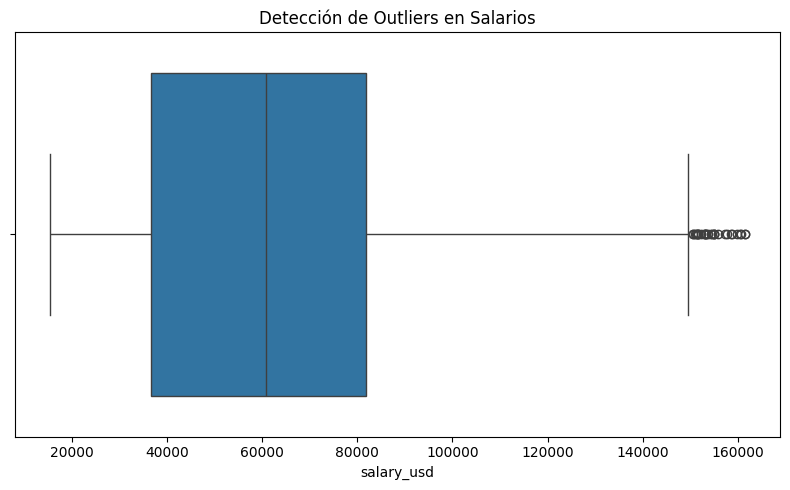

In [ ]:
# Detección de outliers en salarios
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['salary_usd'])
plt.title('Detección de Outliers en Salarios')
plt.tight_layout()
plt.show()

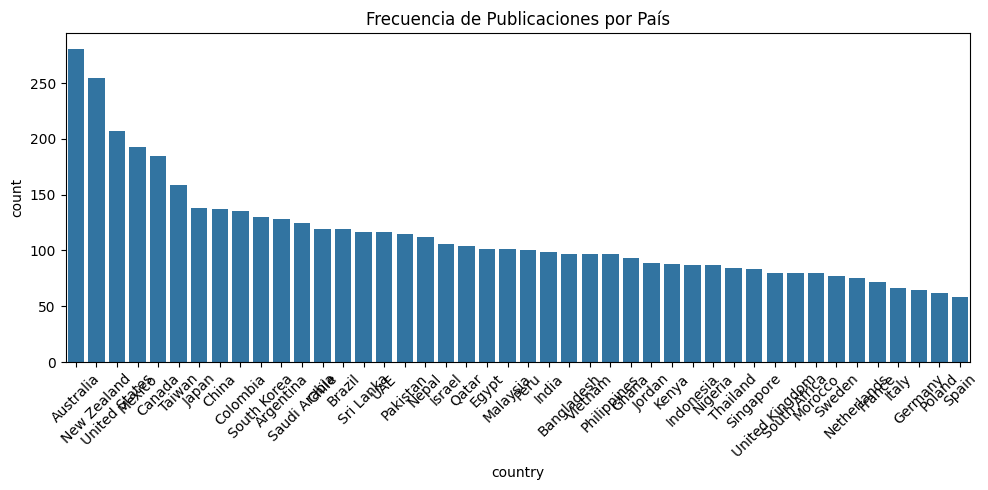

In [ ]:
# Frecuencia por país
plt.figure(figsize=(10, 5))
sns.countplot(x='country', data=df, order=df['country'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Frecuencia de Publicaciones por País')
plt.tight_layout()
plt.show()

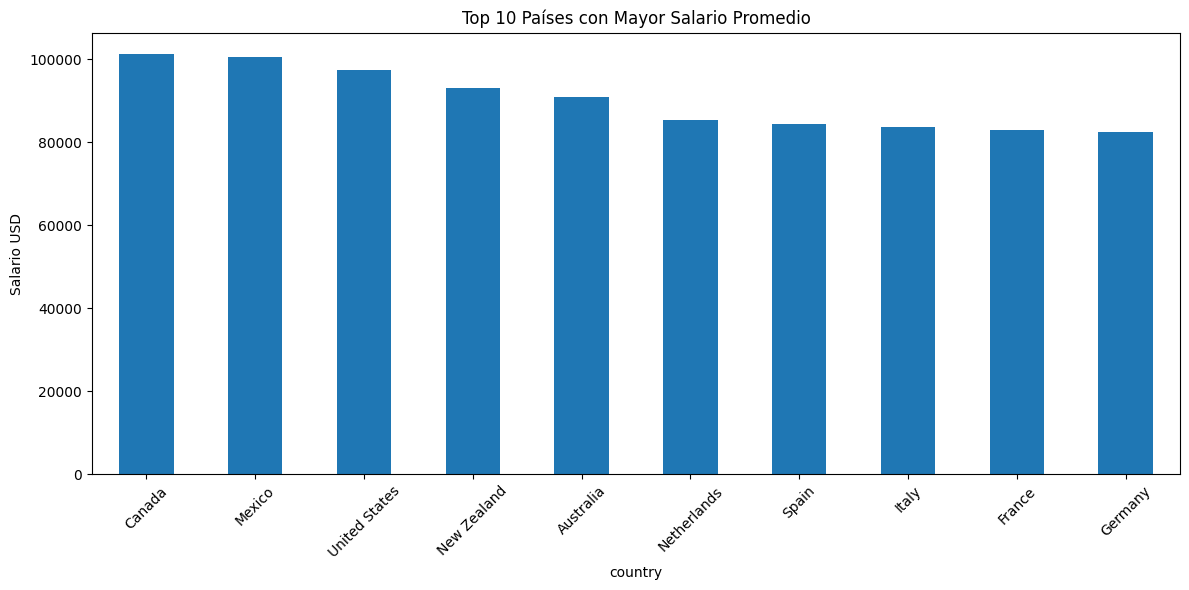

In [ ]:
# Top 10 países con mayor salario promedio
df_country = df.groupby('country')['salary_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
df_country.head(10).plot(kind='bar')
plt.title('Top 10 Países con Mayor Salario Promedio')
plt.ylabel('Salario USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

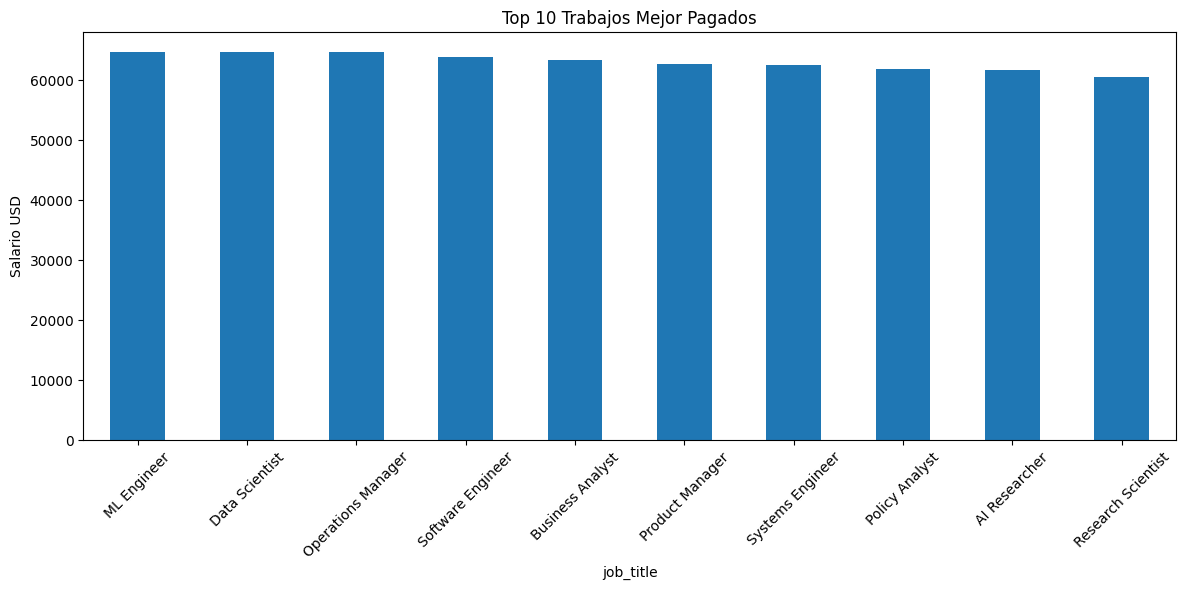

In [ ]:
# Top 10 trabajos mejor pagados
df_job = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
df_job.head(10).plot(kind='bar')
plt.title('Top 10 Trabajos Mejor Pagados')
plt.ylabel('Salario USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

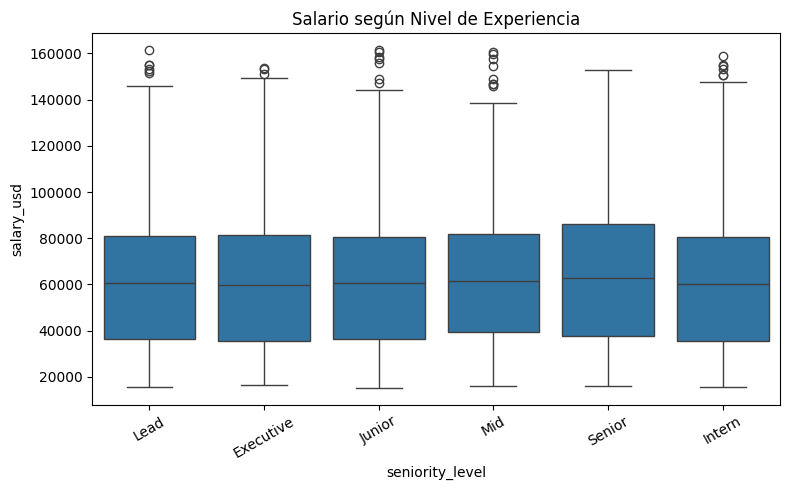

In [ ]:
# Salario según nivel de experiencia
plt.figure(figsize=(8, 5))
sns.boxplot(x='seniority_level', y='salary_usd', data=df)
plt.title('Salario según Nivel de Experiencia')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Detección de Outliers con IQR

In [ ]:
Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['salary_usd'] < Q1 - 1.5 * IQR) | (df['salary_usd'] > Q3 + 1.5 * IQR)]
print(f"Cantidad de outliers detectados: {outliers.shape[0]}")
display(outliers[['job_title', 'country', 'salary_usd']].head(10))

Cantidad de outliers detectados: 30


,job_title,country,salary_usd
259,Product Manager,Canada,157355
334,ML Engineer,United States,152964
355,Research Scientist,Canada,154969
412,AI Researcher,Canada,158734
604,Business Analyst,Mexico,151316
639,Business Analyst,Canada,154995
738,Operations Manager,United States,153069
781,Policy Analyst,United States,153397
952,Business Analyst,Canada,151557
1047,Operations Manager,Mexico,152987


## 9. Codificación de Variables Categóricas

In [ ]:
!pip install category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [ ]:
# One-Hot Encoding para 'region' (cardinalidad moderada)
ohe = OneHotEncoder(sparse_output=False)
region_encoded = ohe.fit_transform(df[['region']])
region_df = pd.DataFrame(
    region_encoded,
    columns=ohe.get_feature_names_out(['region']),
    index=df.index
)
display(region_df.head())

,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Binary Encoding para 'city' (alta cardinalidad)
be = ce.BinaryEncoder(cols=['city'])
df_binary_city = be.fit_transform(df['city'])

# Construir df_final uniendo todo y eliminando columnas originales codificadas
df_final = pd.concat([df.drop(columns=['region', 'city']), region_df, df_binary_city], axis=1)

print(f"Total de columnas tras codificación: {len(df_final.columns)}")
display(df_final.head())

Total de columnas tras codificación: 33


,job_id,posting_year,country,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia,city_0,city_1,city_2,city_3
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Future Solutions,Medium,Energy,Data Scientist,Executive,False,,0.04,"Research, SQL, Business Analysis, Python, Clou...",,62045,-3.98,0.71,False,High,19,Emerging,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,Future Analytics,Startup,Finance,Product Manager,Junior,False,,0.15,"Statistics, Project Management, Cloud Computin...",,27035,3.55,0.86,False,High,2,Emerging,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,1
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Global Technologies,Large,Government,Data Scientist,Mid,False,,0.19,"Cloud Computing, SQL, Project Management, Comm...",,72894,-2.80,0.70,False,Low,15,Emerging,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,,0.11,"SQL, Python, Communication, Software Engineeri...",,57215,0.85,0.87,False,High,13,Emerging,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1


## 10. Escalamiento de Variables Numéricas

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_a_escalar = ['salary_usd', 'ai_intensity_score', 'automation_risk_score']

scaler = StandardScaler()
df_final_esc = df_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final_esc[cols_a_escalar])

print("Primeras 5 filas con datos estandarizados:")
display(df_final_esc[cols_a_escalar].head())

Primeras 5 filas con datos estandarizados:


,salary_usd,ai_intensity_score,automation_risk_score
0,-0.048052,1.794032,-1.904845
1,-0.033447,-0.848854,0.495333
2,-1.147418,-0.471298,1.095377
3,0.311753,-0.334006,0.455330
4,-0.187131,-0.608591,1.135380


## 11. Distribuciones y Matriz de Correlación

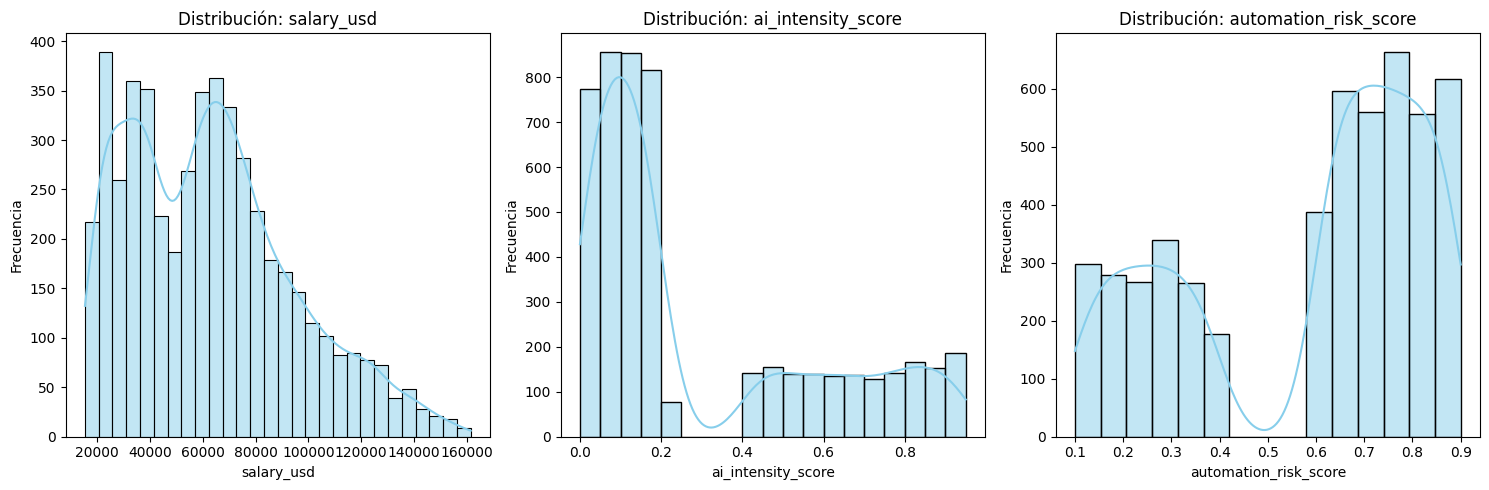

In [ ]:
cols_numericas = ['salary_usd', 'ai_intensity_score', 'automation_risk_score']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_final[col], kde=True, color='skyblue')
    plt.title(f'Distribución: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

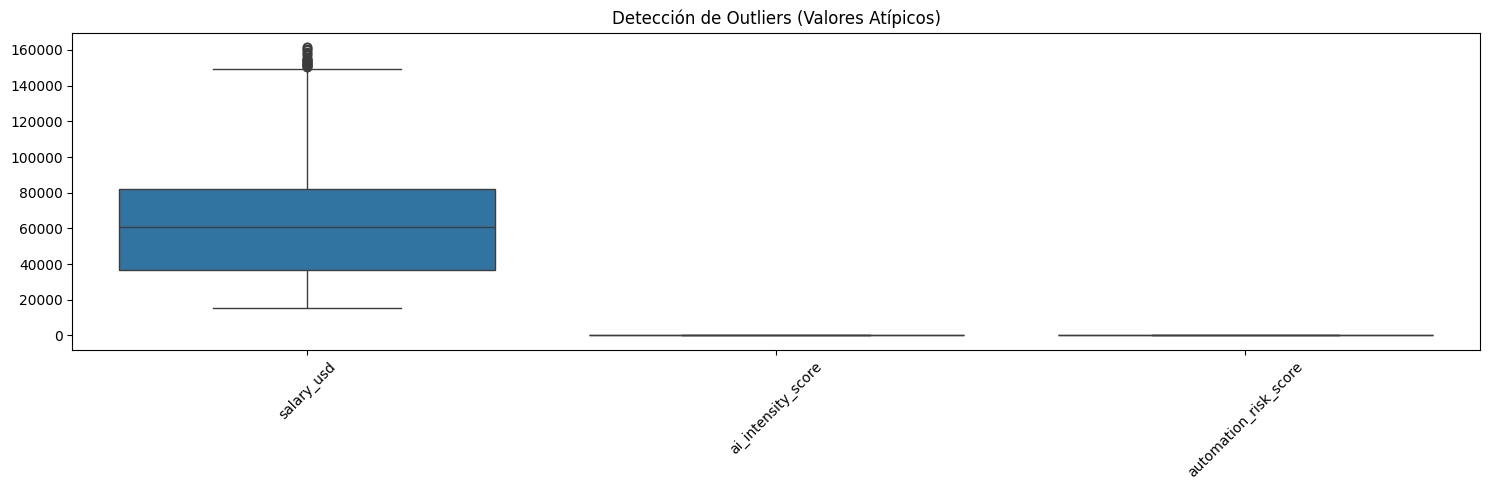

In [ ]:
# Boxplot conjunto para detectar outliers
plt.figure(figsize=(15, 5))
sns.boxplot(data=df_final[cols_numericas])
plt.xticks(rotation=45)
plt.title('Detección de Outliers (Valores Atípicos)')
plt.tight_layout()
plt.show()

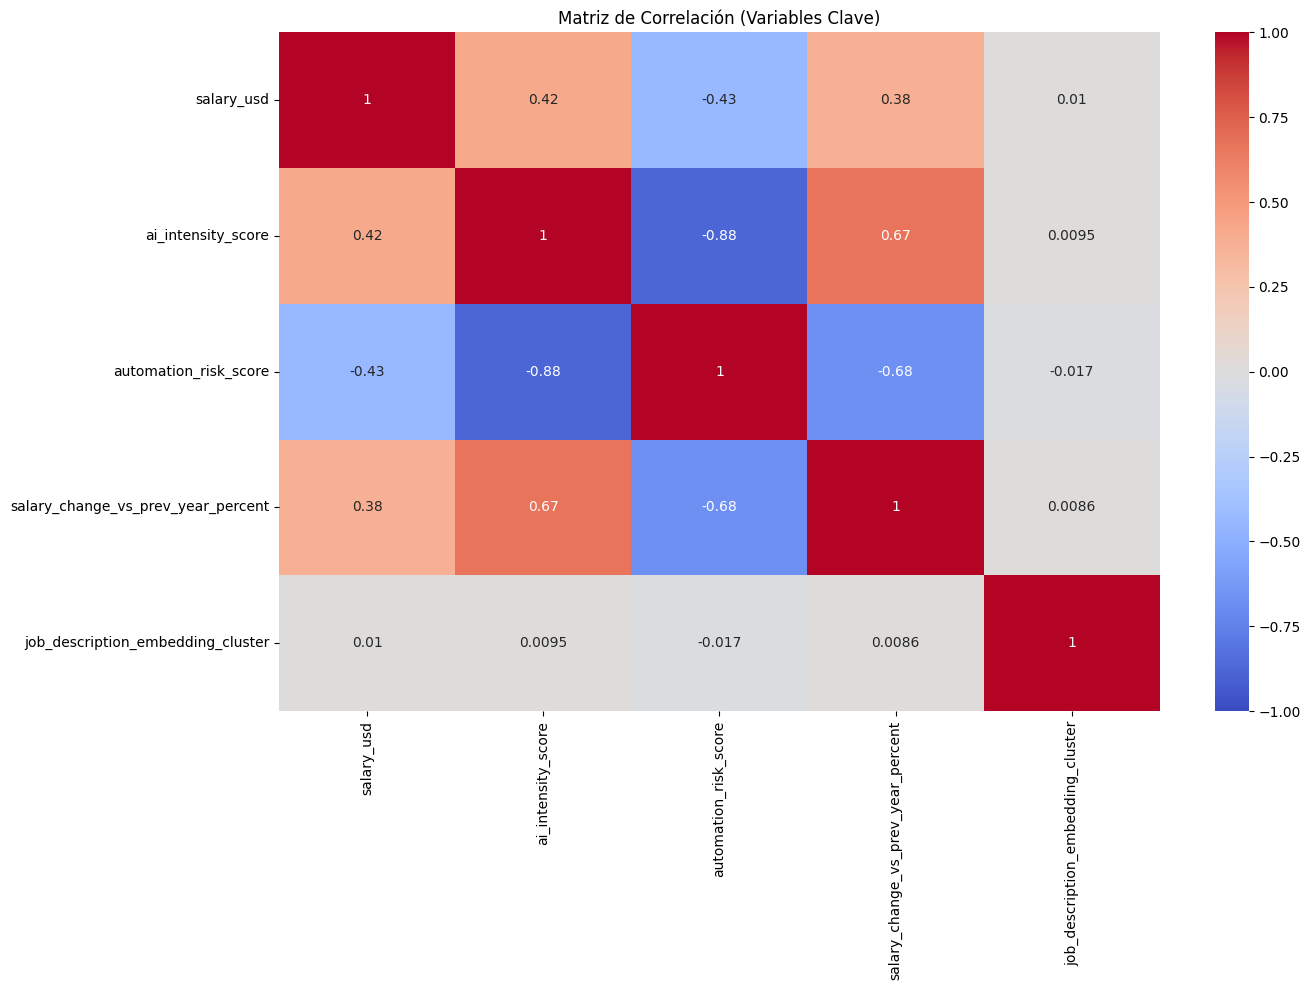

In [ ]:
# Matriz de correlación numérica
df_numeric = df_final_esc.select_dtypes(include=['number', 'bool'])
corr_matrix = df_numeric.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_numeric[['salary_usd', 'ai_intensity_score', 'automation_risk_score',
                'salary_change_vs_prev_year_percent', 'job_description_embedding_cluster']].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1
)
plt.title('Matriz de Correlación (Variables Clave)')
plt.tight_layout()
plt.show()

---
## 12. Preparación de Datos para Modelado

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Selección de features y target principal
features = [
    'ai_intensity_score',
    'automation_risk_score',
    'salary_usd',
    'salary_change_vs_prev_year_percent',
    'job_description_embedding_cluster',
    'ai_mentioned',
    'reskilling_required'
]

target_clf = 'ai_job_displacement_risk'   # Clasificación (Opción 1 y 2)
target_reg = 'salary_usd'                 # Regresión (Opción 3)

# Codificar variable objetivo ordinal
le = LabelEncoder()
df['displacement_encoded'] = le.fit_transform(df[target_clf])
print("Clases:", le.classes_)

# Dataset limpio para modelos
df_model = df[features + ['displacement_encoded']].copy()
df_model['ai_mentioned'] = df_model['ai_mentioned'].astype(int)
df_model['reskilling_required'] = df_model['reskilling_required'].astype(int)

print("\nForma del dataset de modelado:", df_model.shape)
display(df_model.head())

Clases: ['High' 'Low' 'Medium']

Forma del dataset de modelado: (5000, 8)


,ai_intensity_score,automation_risk_score,salary_usd,salary_change_vs_prev_year_percent,job_description_embedding_cluster,ai_mentioned,reskilling_required,displacement_encoded
0,0.81,0.11,61586,12.68,14,1,1,1
1,0.04,0.71,62045,-3.98,19,0,0,0
2,0.15,0.86,27035,3.55,2,0,0,0
3,0.19,0.70,72894,-2.80,15,0,0,1
4,0.11,0.87,57215,0.85,13,0,0,0


In [ ]:
# División train/test (80/20)
X = df_model.drop(columns=['displacement_encoded'])
y_clf = df_model['displacement_encoded']
y_reg = df[target_reg]

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

Train: 4000 filas | Test: 1000 filas


---
## Modelo 1 — Random Forest Classifier

> **Predice:** `ai_job_displacement_risk` (Low / Medium / High)  
> **Ventaja:** Alta precisión, maneja múltiples variables, entrega importancia de features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Entrenamiento
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_clf_train)

# Predicción
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("=== Random Forest — Métricas ===")
print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_rf):.4f}")
print()
print(classification_report(y_clf_test, y_pred_rf, target_names=le.classes_))

=== Random Forest — Métricas ===
Accuracy: 0.3110

              precision    recall  f1-score   support

        High       0.32      0.33      0.33       325
         Low       0.31      0.30      0.30       344
      Medium       0.30      0.31      0.30       331

    accuracy                           0.31      1000
   macro avg       0.31      0.31      0.31      1000
weighted avg       0.31      0.31      0.31      1000



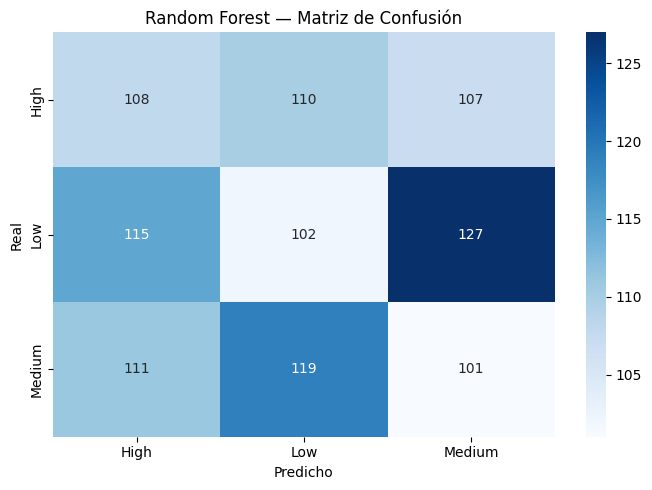

In [ ]:
# Matriz de confusión
plt.figure(figsize=(7, 5))
cm_rf = confusion_matrix(y_clf_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

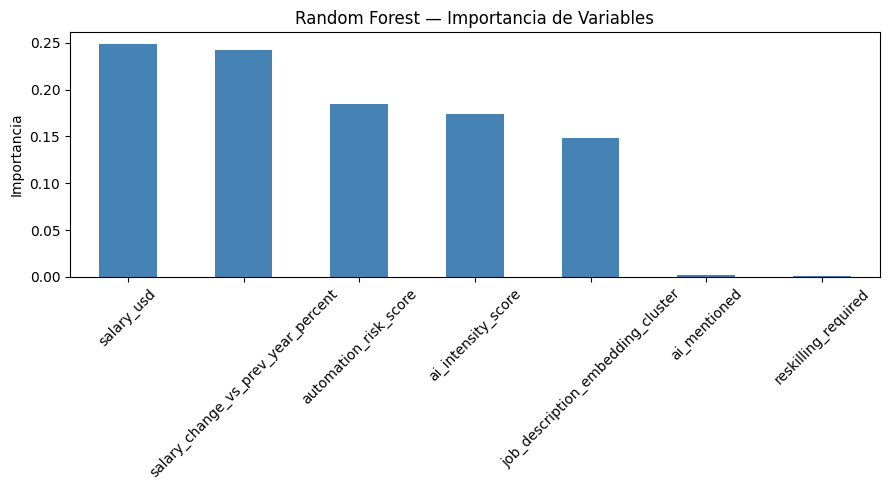


Top variables más importantes:


,Variable,Importancia
0,salary_usd,0.248653
1,salary_change_vs_prev_year_percent,0.241841
2,automation_risk_score,0.184153
3,ai_intensity_score,0.174128
4,job_description_embedding_cluster,0.148104
5,ai_mentioned,0.001649
6,reskilling_required,0.001472


In [ ]:
# Importancia de variables
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_importance.plot(kind='bar', color='steelblue')
plt.title('Random Forest — Importancia de Variables')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop variables más importantes:")
display(feat_importance.reset_index().rename(columns={'index': 'Variable', 0: 'Importancia'}))

---
## Modelo 2 — Árbol de Decisión (Decision Tree)

> **Predice:** `ai_job_displacement_risk` y `reskilling_required`  
> **Ventaja:** Totalmente interpretable, se puede visualizar con reglas claras.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# --- Árbol 1: Predice displacement risk ---
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_clf_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Árbol de Decisión — Riesgo de Desplazamiento ===")
print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_dt):.4f}")
print()
print(classification_report(y_clf_test, y_pred_dt, target_names=le.classes_))

=== Árbol de Decisión — Riesgo de Desplazamiento ===
Accuracy: 0.3450

              precision    recall  f1-score   support

        High       0.32      0.02      0.03       325
         Low       0.34      0.98      0.51       344
      Medium       0.50      0.01      0.02       331

    accuracy                           0.34      1000
   macro avg       0.39      0.33      0.19      1000
weighted avg       0.39      0.34      0.19      1000



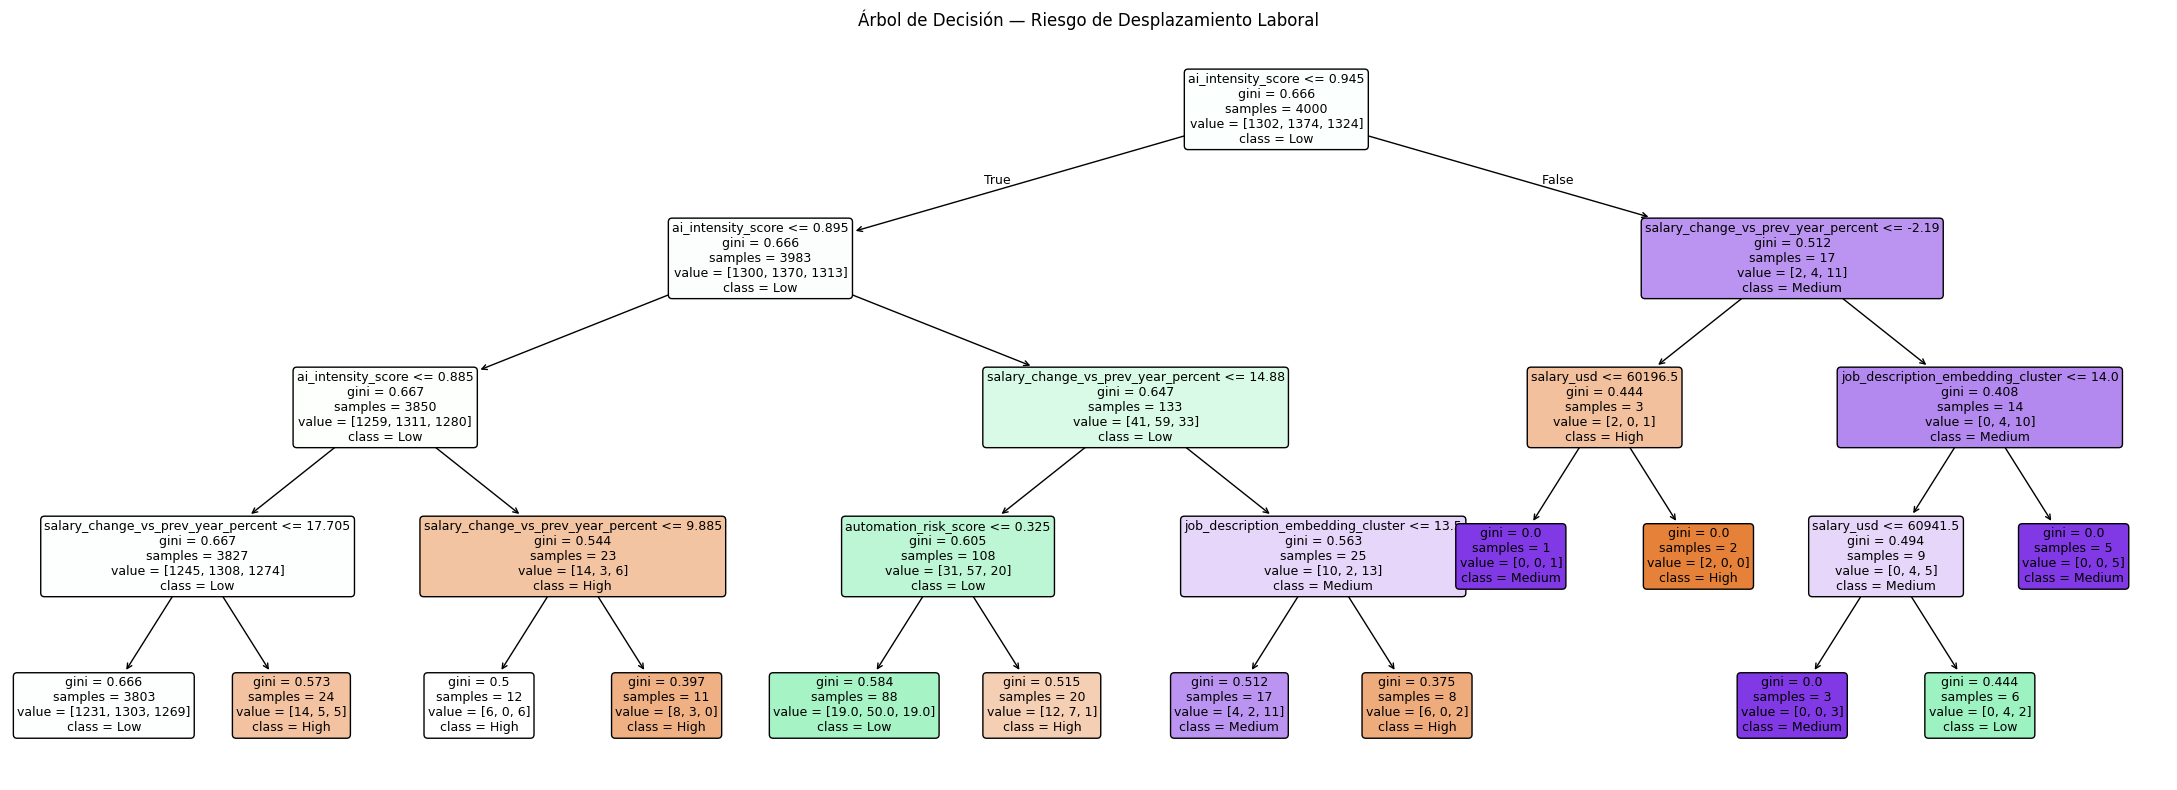

In [ ]:
# Visualización del árbol
plt.figure(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Árbol de Decisión — Riesgo de Desplazamiento Laboral')
plt.tight_layout()
plt.show()

In [ ]:
# --- Árbol 2: Predice reskilling_required ---
y_reskill = df_model['reskilling_required']
_, _, y_rsk_train, y_rsk_test = train_test_split(X, y_reskill, test_size=0.2, random_state=42)

dt_reskill = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_reskill.fit(X_train, y_rsk_train)
y_pred_rsk = dt_reskill.predict(X_test)

print("=== Árbol de Decisión — Reskilling Requerido ===")
print(f"Accuracy: {accuracy_score(y_rsk_test, y_pred_rsk):.4f}")
print()
print(classification_report(y_rsk_test, y_pred_rsk, target_names=['No Requiere', 'Requiere']))

=== Árbol de Decisión — Reskilling Requerido ===
Accuracy: 0.6500

              precision    recall  f1-score   support

 No Requiere       0.65      0.99      0.79       651
    Requiere       0.45      0.01      0.03       349

    accuracy                           0.65      1000
   macro avg       0.55      0.50      0.41      1000
weighted avg       0.58      0.65      0.52      1000



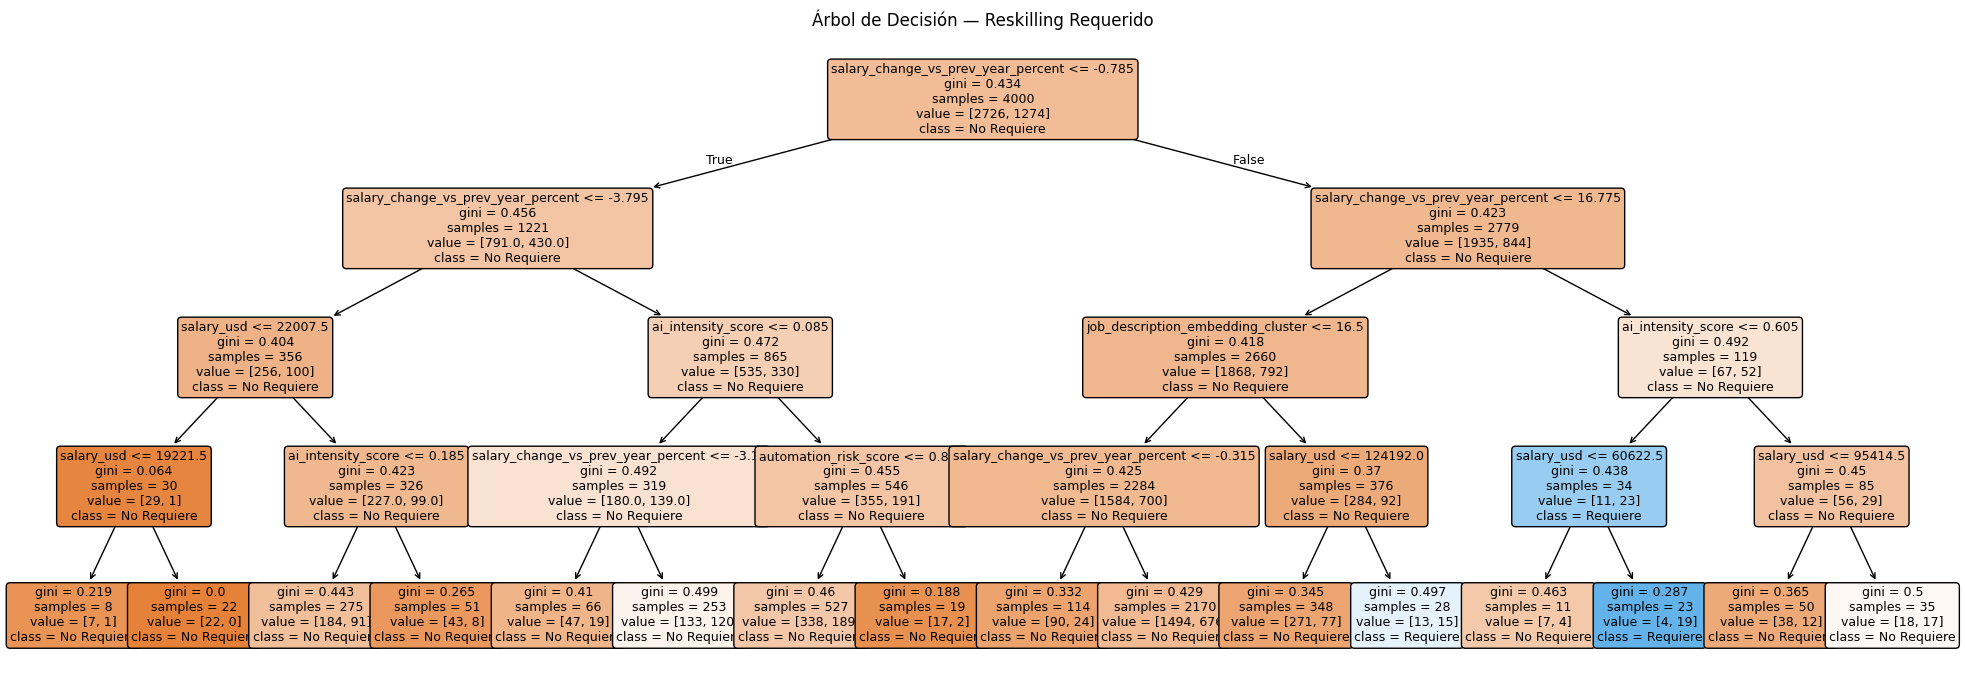

In [ ]:
# Visualización árbol reskilling
plt.figure(figsize=(20, 7))
plot_tree(
    dt_reskill,
    feature_names=X.columns.tolist(),
    class_names=['No Requiere', 'Requiere'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Árbol de Decisión — Reskilling Requerido')
plt.tight_layout()
plt.show()

---
## Modelo 3 — Pipeline: Regresión Lineal + Regresión Logística Multinomial

> **Predice:**  
> - `salary_usd` → Regresión Lineal Múltiple (variable continua)  
> - `ai_job_displacement_risk` → Regresión Logística Multinomial (variable ordinal)  
> **Ventaja:** Cubre dos tipos de predicción en un solo bloque, aprovecha el escalamiento previo.

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score

# === 3A: Regresión Lineal — Predicción de Salario ===
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)
y_pred_lr = lr_model.predict(X_test)

mse = mean_squared_error(y_reg_test, y_pred_lr)
r2  = r2_score(y_reg_test, y_pred_lr)

print("=== Regresión Lineal — Predicción de Salario (USD) ===")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {mse**0.5:,.2f}")
print(f"R²   : {r2:.4f}")

=== Regresión Lineal — Predicción de Salario (USD) ===
MSE  : 1,047,005,221.66
RMSE : 32,357.46
R²   : -0.0043


/tmp/ipykernel_1224/233902774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Variable', y='Coeficiente', palette='coolwarm')


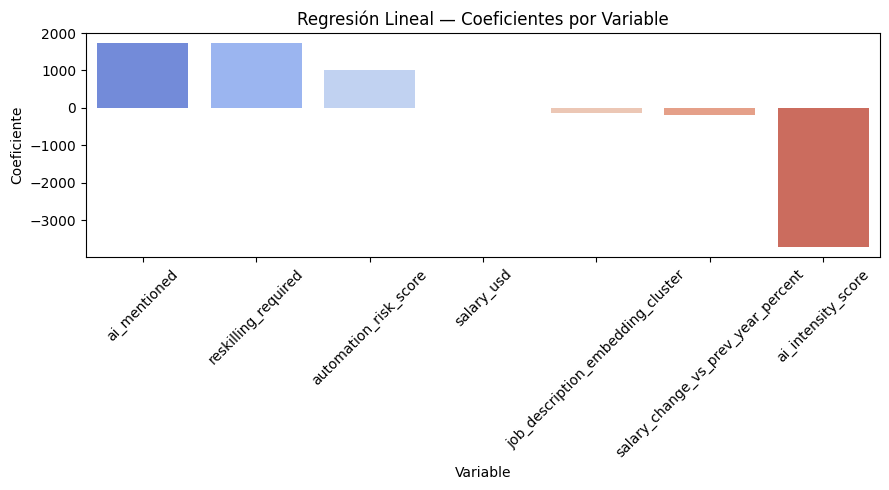

,Variable,Coeficiente
5,ai_mentioned,1732.384042
6,reskilling_required,1732.384042
1,automation_risk_score,1005.163244
2,salary_usd,0.017327
4,job_description_embedding_cluster,-129.030464
3,salary_change_vs_prev_year_percent,-201.250422
0,ai_intensity_score,-3724.249022


In [ ]:
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_
}).sort_values('Coeficiente', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df, x='Variable', y='Coeficiente', palette='coolwarm')
plt.title('Regresión Lineal — Coeficientes por Variable')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(coef_df)

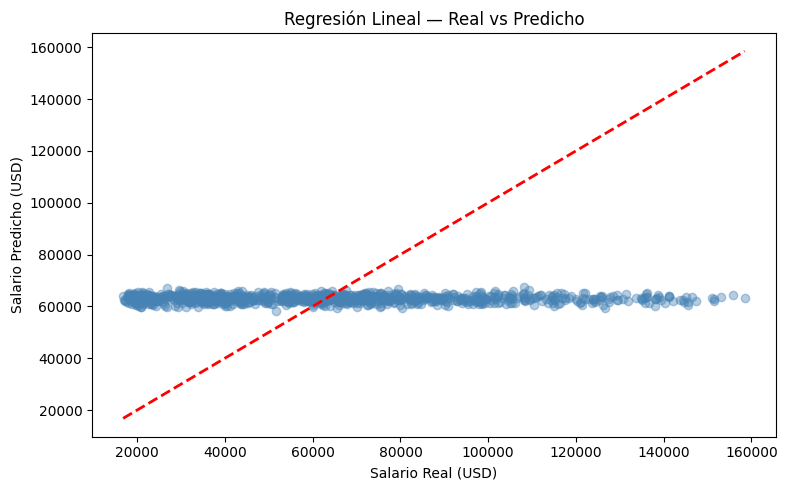

In [ ]:
# Gráfico real vs predicho
plt.figure(figsize=(8, 5))
plt.scatter(y_reg_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel('Salario Real (USD)')
plt.ylabel('Salario Predicho (USD)')
plt.title('Regresión Lineal — Real vs Predicho')
plt.tight_layout()
plt.show()

In [ ]:
# === 3B: Regresión Logística Multinomial — Predicción de Displacement Risk ===
log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=42)
log_model.fit(X_train, y_clf_train)
y_pred_log = log_model.predict(X_test)

print("=== Regresión Logística Multinomial — Riesgo de Desplazamiento ===")
print(f"Accuracy: {accuracy_score(y_clf_test, y_pred_log):.4f}")
print()
print(classification_report(y_clf_test, y_pred_log, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Regresión Logística Multinomial — Riesgo de Desplazamiento ===
Accuracy: 0.3560

              precision    recall  f1-score   support

        High       0.43      0.05      0.09       325
         Low       0.36      0.67      0.47       344
      Medium       0.35      0.33      0.34       331

    accuracy                           0.36      1000
   macro avg       0.38      0.35      0.30      1000
weighted avg       0.38      0.36      0.30      1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


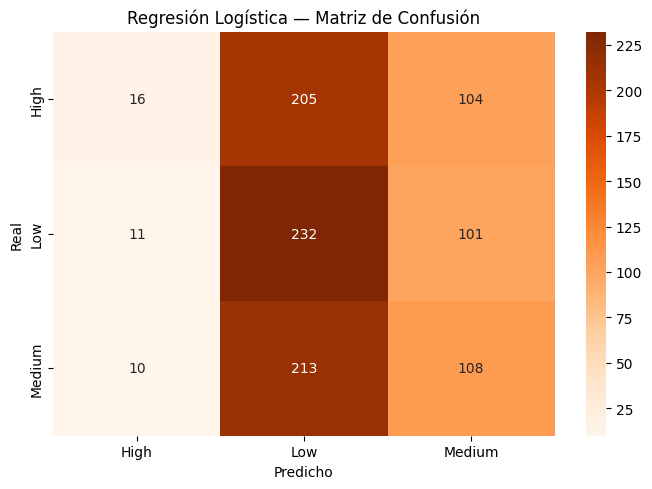

In [ ]:
# Matriz de confusión regresión logística
plt.figure(figsize=(7, 5))
cm_log = confusion_matrix(y_clf_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Regresión Logística — Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

---
## 16. Comparación Final de Modelos

,Modelo,Accuracy,F1-Score (macro)
0,Random Forest,0.311,0.3111
1,Árbol de Decisión,0.345,0.1874
2,Reg. Logística Multinomial,0.356,0.2969


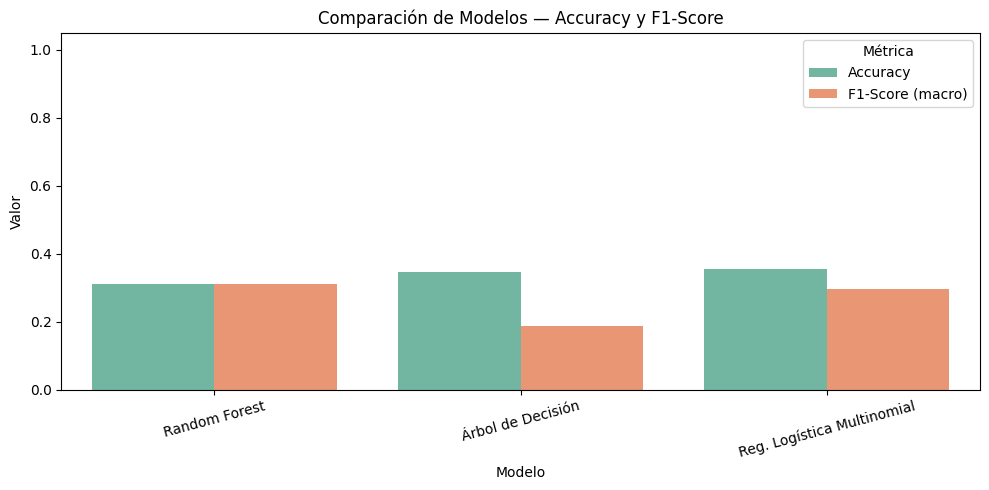

In [ ]:
# Comparar los 3 modelos de clasificación
from sklearn.metrics import accuracy_score, f1_score

resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'Árbol de Decisión', 'Reg. Logística Multinomial'],
    'Accuracy': [
        accuracy_score(y_clf_test, y_pred_rf),
        accuracy_score(y_clf_test, y_pred_dt),
        accuracy_score(y_clf_test, y_pred_log)
    ],
    'F1-Score (macro)': [
        f1_score(y_clf_test, y_pred_rf, average='macro'),
        f1_score(y_clf_test, y_pred_dt, average='macro'),
        f1_score(y_clf_test, y_pred_log, average='macro')
    ]
}).round(4)

display(resultados)

# Gráfico comparativo
resultados_melted = resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_melted, x='Modelo', y='Valor', hue='Métrica', palette='Set2')
plt.title('Comparación de Modelos — Accuracy y F1-Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 📋 Conclusiones del Modelado

| Modelo | Fortaleza Principal | Uso Recomendado |
|---|---|---|
| **Random Forest** | Mayor precisión, importancia de variables | Modelo principal de predicción |
| **Árbol de Decisión** | Interpretabilidad visual, reglas claras | Explicación académica y presentación |
| **Reg. Lineal + Logística** | Cubre variables continuas y categóricas | Análisis estadístico complementario |

El modelo con mejor rendimiento general es **Random Forest**, seguido por **Regresión Logística Multinomial** y finalmente el **Árbol de Decisión** (más simple pero totalmente explicable).